In [ ]:
# Let's import all your dependencies first

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
df.drop(["Channel", "Region"], axis = 1, inplace = True)


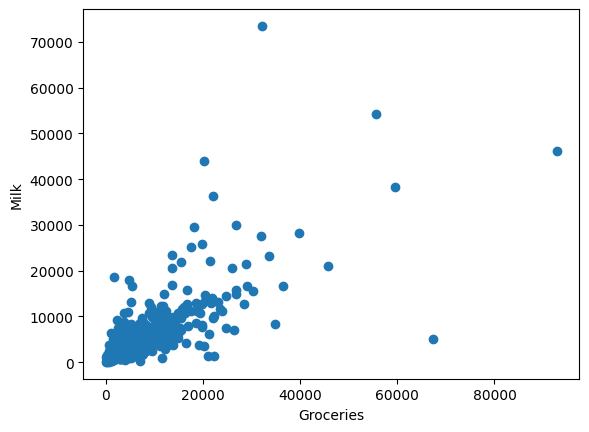

In [ ]:
x = df['Grocery']
y = df['Milk']

plt.scatter(x,y)
plt.xlabel("Groceries")
plt.ylabel("Milk")
plt.show()


1. ESCALAR LOS DATOS
2. CONSTRUIR EL MODELO DE DBSCAN CON TODAS LAS COLUMNAS
3. REPRESENTAR EL GRAFICO ANTERIOR PINTANDO EN COLORES DEPENDIENDO DE EL CLUSTERASIGNADO
4. JUGAR CON LOS HIPERPARAMETROS
  

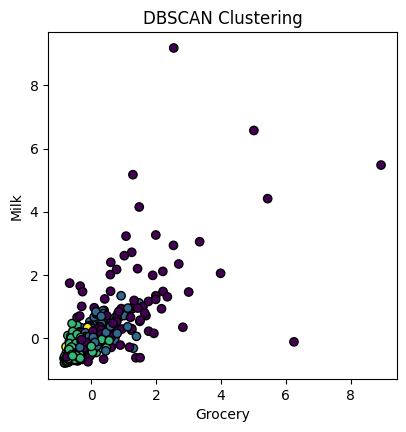

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('/content/Wholesale customers data.csv')

# Estandarizar los datos
stscaler = StandardScaler().fit(df)
df_scaled = stscaler.transform(df)

# Convertir el array transformado de nuevo a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

# Aplicar DBSCAN
dbsc = DBSCAN(eps=1, min_samples=25).fit(df_scaled)
labels = dbsc.labels_

# Identificar muestras principales
core_samples = np.zeros_like(labels, dtype=bool)
core_samples[dbsc.core_sample_indices_] = True

# Seleccionar las columnas Grocery y Milk para la gráfica
x = df_scaled['Grocery']
y = df_scaled['Milk']

# Crear el gráfico
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
scatter = ax.scatter(
    x,
    y,
    c=labels,
    marker='o',
    edgecolor='black'
)
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.title('DBSCAN Clustering')
plt.show()

